# PythonCodeLABook 5.19.26 Will Newman
- Python companion to MATLAB scripts used in LABook.
- Each cell will be mostly self contained, but will all require importing the numpy and matplotlib libraries. Run the next cell now.
- Tips and tricks: shift+enter runs current cell and moves to the next. ctrl+enter runs current cell. ctrl+'/' is comment/uncomment

In [113]:
# Import numpy and matplotlib
import numpy as np # numerical python package. Ex: Lets us define n-dimensional arrays and work with them using LA
from matplotlib import pyplot as plt # Figure generating package. Works similarly to MATLAB's figure generation

## Exercise E8.6: Recording frequency 

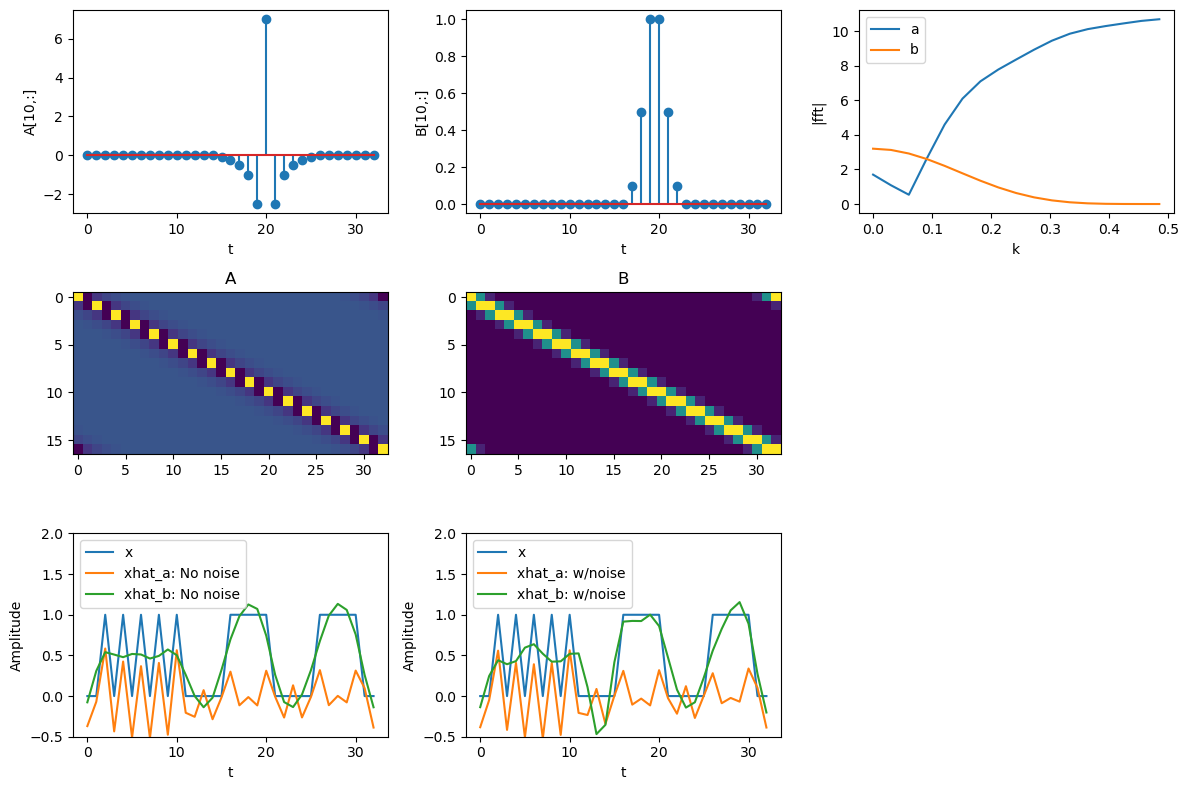

In [114]:
from numpy import fft # Import fft from numpy
from numpy.linalg import pinv # import pinv
# Generate two impulse responses:
a, b, t = np.zeros((1,33)), np.zeros((1,33)), np.arange(0,33) # start with zero vectors. In python you have to index the first channel in a 1xn array. 

# Add in specific values for a and b in time domain
a[0,0:6], a[0,-5:] = np.array([7.0, -2.5, -1.0, -0.5, -0.25, -0.1]), np.array([-0.1, -0.25, -0.5, -1.0, -2.5]) # a ',' separates each part
b[0,0:3], b[0,-3:] = np.array([1.0, 0.5, 0.1]), np.array([0.1, 0.5, 1.0]) 

# frq domain impulse response
u = np.arange(0,0.5/(t[1]-t[0]),1/len(t)) # + frq axis
fa, fb = np.abs(fft.fft(a)), np.abs(fft.fft(b)) # frq response of system (impulse response spectra)

# Generate circulant matrices for convolution operation
num_rows = np.arange(3,N+2,2)
A, B, N, icnt = np.zeros((len(num_rows)+1,len(a[0,:]))), np.zeros((len(num_rows)+1,len(b[0,:]))), len(b[0,:]), 0
A[0,:], B[0,:] = a, b
for j in num_rows:
    icnt = int((j+1)/2)-1
    A[icnt,0:j-1] = a[0,N-j+1:]
    A[icnt,j-1:] = a[0,0:N-j+1]
    B[icnt,0:j-1] = b[0,N-j+1:]
    B[icnt,j-1:] = b[0,0:N-j+1]
    
# Generate input function
x = np.zeros((1,len(t))) # initialize
x[0,2:12:2] =  np.array([1, 1, 1, 1, 1]) 
x[0,16:21] = np.array([1, 1, 1, 1, 1]) 
x[0,26:31]  = np.array([1, 1, 1, 1, 1]) # assign signal intensity 
n = 0.2*np.random.randn(icnt+1,1) # additive noise

y1A, y1B, y2A, y2B = A@x.T, B@x.T, A@x.T + n, B@x.T + n # '@' does matrix mult. All acquisitions are recoreded in this line

# Uncomment below to see results
# fig, ax = plt.subplots(1,2)
# ax[0].plot(y1A,label='y1A - no noise')
# ax[0].plot(y2A,label='y2A - noise')
# ax[1].plot(y1B,label='y2B - no noise')
# ax[1].plot(y2B,label='y1B - noise')
# ax[0].legend()
# ax[1].legend()


# Main Figure: I go a bit out of order here, but use the indices to match with the plot 
fig, ax = plt.subplots(3,3,figsize=(12,8))
# use imshow() to make an image of the circulant matrices
ax[1,0].imshow(A)
ax[1,0].set_title('A')

ax[1,1].imshow(B)
ax[1,1].set_title('B')

# Plot one line of each matrix (impulse response)
ax[0,0].stem(t,A[10,:])
ax[0,0].set_ylabel('A[10,:]')
ax[0,0].set_xlabel('t')

ax[0,1].stem(t,B[10,:])
ax[0,1].set_ylabel('B[10,:]')
ax[0,1].set_xlabel('t')

# frq spectra of each impulse response function
ax[0,2].plot(u,fa[0,0:icnt+1])
ax[0,2].plot(u,fb[0,0:icnt+1])
ax[0,2].set_xlabel('k')
ax[0,2].set_ylabel('|fft|')
ax[0,2].legend(('a','b'))

# Next two blocks estimate x from noise free or noisy y and impulse response A or B. 
ax[2,0].plot(t,x[0,:],label='x')
ax[2,0].plot(t,pinv(A)@y1A,label='xhat_a: No noise')
ax[2,0].plot(t,pinv(B)@y1B,label='xhat_b: No noise')
ax[2,0].set_ylim(-0.5,2)
ax[2,0].legend(loc='best')
ax[2,0].set_xlabel('t')
ax[2,0].set_ylabel('Amplitude')

ax[2,1].plot(t,x[0,:],label='x')
ax[2,1].plot(t,pinv(A)@y2A,label='xhat_a: w/noise')
ax[2,1].plot(t,pinv(B)@y2B,label='xhat_b: w/noise')
ax[2,1].set_ylim(-0.5,2)
ax[2,1].legend(loc='best')
ax[2,1].set_xlabel('t')
ax[2,1].set_ylabel('Amplitude')

# Delete unwanted blocks
fig.delaxes(ax[1, 2])
fig.delaxes(ax[2, 2])
fig.tight_layout()

## Exercise 8.7: A third-order polynomial model
- I highly encourage the user to change sigma and watch what happens to the plots. See if you can adjust sigma such that the conclusions about the choice of polynomial order in E8.7 change.
- Adjust the code to automate the choice of optimal polynomial order and show how the choice changes as a function of decreasing SNR (increasing sigma). This requires an additional for loop.

Target beta: b0 = 1000.0, b1 = -20.0, b2 = -8.0, b3 = 0.5
beta from y1: b0 = 942.97, b1 = 8.36, b2 = -11.90, b3 = 0.64
beta from y2: b0 = 1027.55, b1 = -64.91, b2 = 5.28, b3 = -0.51


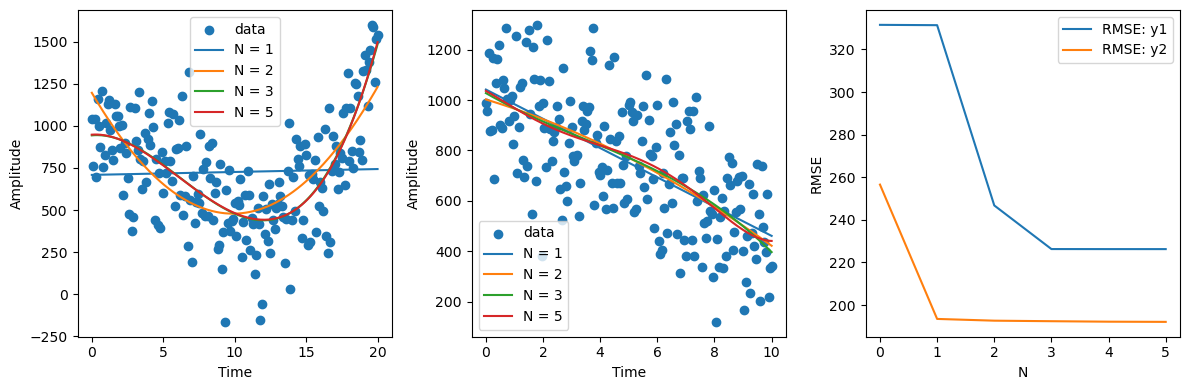

In [115]:
from numpy.linalg import pinv # import pinv
dt = 0.1 # step size
sigma = 200 # standard deviation for i.i.d. MVN
t = np.arange(0,20+dt,dt) # create time vector. Creates an (N,) array NOT AN (1,N) array like MATLAB
# print(f'The shape of t is: {t.shape}') # uncomment to print
b = np.array([1000, -20, -8, 0.5]) # true beta values
t.shape, b.shape = (1, len(t)), (1, len(b)) # change into row arrays
R1, R2 = np.zeros(6), np.zeros(6) # (6,) initialized array of eventual RMSE values

# generate data set 1 (y1)
n1 = sigma*np.random.randn(t.shape[0],t.shape[1]) # noise 1 (noise variance = sigma^2)
yp = b[0,0] + b[0,1]*t + b[0,2]*t**2 + b[0,3]*t**3 # signal 1
# SNR = 10*np.log10(np.sum(yp**2)/t1[0,-1]/sigma**2) # uncomment to check SNR
y1 = yp + n1 # measurement 1
# plt.scatter(t[0,:],y1[0,:]) # uncomment to check data

# generate data set 2 (y2)
dt2 = 0.05 # step size for second time trace
t2 = np.arange(0,10+dt2,dt2) # create time vector 2 (10s)
t2.shape = (1, len(t2))# reshape to row vector
n2 = sigma*np.random.randn(t2.shape[0],t2.shape[1]) # noise 2 (same distribution)
y2 = b[0,0] + b[0,1]*t2 + b[0,2]*t2**2 + b[0,3]*t2**3 + n2

# Create Design Matrices (T matrix in LABook)
T1 = np.concatenate((np.ones((len(t.T),1)),t.T, t.T**2, t.T**3, t.T**4, t.T**5), axis=1) # time matrix 1
T2 = np.concatenate((np.ones((len(t2.T),1)),t2.T, t2.T**2, t2.T**3, t2.T**4, t2.T**5), axis=1) # time matrix 2

# I do this next part a little different than Mike. 
# In the MATLAB code, the fits are performed and selected to plot to screen. 
# Here I will run all fits and save the beta values and each fit to a list of numpy arrays. 
# Once run, I will index through my lists to plot the fits. 
# I also code the RMS eq directly. 

# fit data with polynomial models of order 0-5
b1_all, b2_all, z1_all, z2_all = [], [], [], [] # create empty lists to store the results
for j in range(6):
    
    T1_sub = T1[:,0:j+1] # sub mat
    b1 = pinv(T1_sub) @ y1.T # find beta1
    b1_all.append(b1) # save params
    z1 = T1_sub @ b1 # z = Tb, the fit
    z1_all.append(z1) # save fit
    R1[j] = np.sqrt(np.sum((z1-y1.T)**2)/len(y1.T)) # RMSE

    
    T2_sub = T2[:,0:j+1] # sub mat
    b2 = pinv(T2_sub) @ y2.T # find beta2
    b2_all.append(b2) # save params
    z2 = T2_sub @ b2 # z = Tb, the fit
    z2_all.append(z2) # save fit
    R2[j] = np.sqrt(np.sum((z2-y2.T)**2)/len(y2.T)) # RMSE

# Main Figure: Plot the data, the fits and the RMSE as a function of poly order
poly_orders = [1,2,3,5] # Choose which polynomial orders (N) to plot
fig, ax = plt.subplots(1,3,figsize=(12,4))
ax[0].scatter(t,y1,label='data') # plot data
ax[1].scatter(t2,y2,label='data')
for idx in poly_orders: # Loop through poly order and plot
    ax[0].plot(t[0,:],z1_all[idx].T[0,:], label='N = '+str(idx))
    ax[1].plot(t2[0,:],z2_all[idx].T[0,:],label='N = '+str(idx))
ax[0].legend() # add descriptors
ax[1].legend()
ax[0].set_xlabel('Time')
ax[0].set_ylabel('Amplitude')
ax[1].set_xlabel('Time')
ax[1].set_ylabel('Amplitude')

ax[2].plot(np.arange(0,6),R1,label='RMSE: y1') # Plot RMSE as a function of polynomial order
ax[2].plot(np.arange(0,6),R2,label='RMSE: y2')
ax[2].legend()
ax[2].set_xlabel('N')
ax[2].set_ylabel('RMSE')
fig.tight_layout()

# display the true N=3 beta values and our two approximations from y1 and y2
print(f'Target beta: b0 = {b[0,0]}, b1 = {b[0,1]}, b2 = {b[0,2]}, b3 = {b[0,3]}')
print(f'beta from y1: b0 = {b1_all[3][0,0]:4.2f}, b1 = {b1_all[3][1,0]:4.2f}, b2 = {b1_all[3][2,0]:4.2f}, b3 = {b1_all[3][3,0]:4.2f}')
print(f'beta from y2: b0 = {b2_all[3][0,0]:4.2f}, b1 = {b2_all[3][1,0]:4.2f}, b2 = {b2_all[3][2,0]:4.2f}, b3 = {b2_all[3][3,0]:4.2f}')


## Exercise 9.1: Numeric Gram-Schmidt Orthonormalization
In python, functions go at the top of a file and are defined before the main code is run. In a jupyter notebook, we can get away with defining a function at the top of our code block. This code is a little different than MGSO. I use a vectorization approach to reduce the number of for loops to 1. Pay close attention to the matrix multiplication as I find the projections. 

First we will define our function. Try to add a block that checks that the right number of linearly independent vectors are present in V. I show a plotted example for two vectors in R^2, but leave 3D plotting to the matlab example.  

[[ 6.66666667e-01 -2.35702260e-01 -7.07106781e-01]
 [ 6.66666667e-01 -2.35702260e-01  7.07106781e-01]
 [ 3.33333333e-01  9.42809042e-01  6.28036983e-16]]
Orthonormal check:
[[ 1.00000000e+00  8.86511593e-17 -5.04251865e-16]
 [ 8.86511593e-17  1.00000000e+00  3.83926555e-16]
 [-5.04251865e-16  3.83926555e-16  1.00000000e+00]]



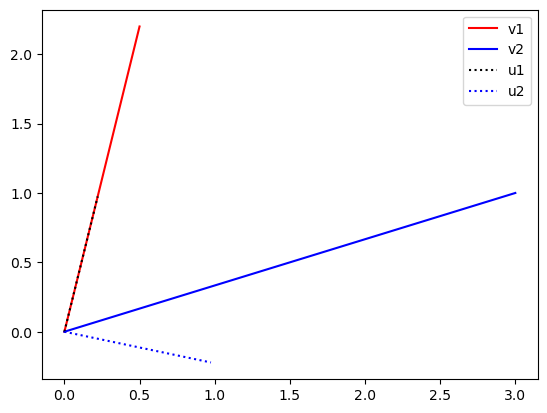

In [116]:
# GS_ortho: gram-schmidt orthonormalization 
# Inputs: V -> a matrix of linearly independent column vectors
# Outputs: Q, R -> A matrix of orthonormal vectors (Q), another matrix that maps Q back to A (R). 
def GS_ortho(V):
    # V = np.array([[1,2,1],[1,2,2],[0.5,2,3]]) # For testing
    Q, R = np.zeros(V.shape), np.zeros(V.shape) # initialize
    Q[:,0] = 1/np.linalg.norm(V[:,0])*V[:,0] # pluck out first vector and normalize
    for i in range(1,Q.shape[1]):
        v = V[:,i] # current vector
        all_proj = (Q[:,0:i].T @ v)/(np.diag(Q[:,0:i].T @ Q[:,0:i]))*Q[:,0:i] # All projection vectors (u^T*v/u^T*u)*u
        sum_proj= np.sum(all_proj,axis=1) # Sum the projection vectors
        Q[:,i] = v - sum_proj # Subtract the sum of the projection vectors
        Q[:,i] = 1/np.linalg.norm(Q[:,i])*Q[:,i] # Normalize
    R = Q.T @ V # Get R from Q and V. 
    return Q, R

# USING THE FUNCTION
# Example from text
V = np.array([[1,2,1],[1,2,2],[0.5,2,3]]) # Example matrix from 9.1
U, _ = GS_ortho(V) # Just get U
print(U)
print(f'Orthonormal check:\n{U@U.T}\n')

# Example for plotting
V2 = np.array([[0.5,3],[2.2,1]])
fig, ax = plt.subplots()
ax.plot([0,V2[0,0]],[0,V2[1,0]],'r')
ax.plot([0,V2[0,1]],[0,V2[1,1]],'b')
U2, _ = GS_ortho(V2) # Just get U
ax.plot([0,U2[0,0]],[0,U2[1,0]],'k:')
ax.plot([0,U2[0,1]],[0,U2[1,1]],'b:')
ax.legend(['v1','v2','u1','u2']);

# Use these to actually draw arrows. 
# ax.arrow(0,0,V2[0,0],V2[0,1],width=0.02)
# ax.arrow(0,0,V2[1,0],V2[1,1],width=0.03)



A few thoughts: 

1. The matrix U we found through orthonormalization matches the code from MATLAB and the textbook. That is always one check to ensure things are working. 
2. Computation noise in my approach leaves some non-zero entries in the orthonormal check which is to be expected. The identity matrix is the result when I try U*U^T, which is another check to ensure the code is working.

Some suggestions to take it further:

1. Try to code the MGSO function from MATLAB exactly in python (nested for loop). Test to see if there are any differences between the results in that code vs. the vectorized version (i.e., timing, output values, functionality).
2. Add checks to ensure the vectors provided are appropriate for the GS procedure. Are they full-rank? Does the rank = the number of vectors? If not, then post an error message.    

## Example 10.5: Comparing Fourier Analysis and Eigenanalysis

C:\Users\willn2\AppData\Local\Temp\ipykernel_2840\693993646.py:35: RuntimeWarning: invalid value encountered in scalar divide
  for j in range(1,17): x[j-1]=(np.sin(8*np.pi*u[j-1]))**2/(8*(np.sin(np.pi*u[j-1]))**2)


Text(0, 0.5, 'A')

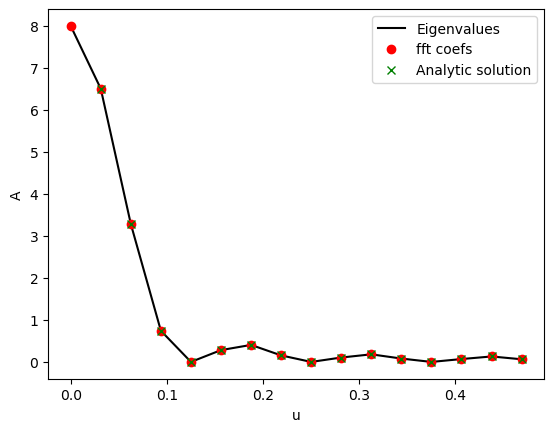

In [117]:
from scipy.linalg import toeplitz
# Initialize n and h
n = np.arange(0,32) # time axis
h = np.zeros((1,32))
N = len(n) # Length of n

# Define h using formula in example
h[0,0:9] = 1-n[0:9]/8
h[0,24::] = n[0:8]/8

# Set up for building the toeplitz matrix
H = toeplitz(h) # column and row

# Uncomment to check plots
# plt.imshow(H)
# plt.stem(h.T)

# frq axis
u = np.arange(0,1/2,1/N) # define u (not inclusive like MATLAB)

# Generate Fourier Basis Functions
Q = np.zeros(H.shape,dtype=np.complex64)
for k in range(1,N+1):
    for p in range(1,N+1):
        Q[k-1,p-1]=np.exp(1j*2*np.pi*(p-1)*(k-1)/N);

F = Q.conj() @ H @ Q/N # Eigen-decompose H with Q. 
FH = np.diag(F) # Fourier coefficients (eigenvalues!)
Fhp = np.fft.fft(h) # using fft
plt.plot(u,np.abs(FH[0:int(N/2)]),'k')
plt.plot(u,np.abs(Fhp[0,0:int(N/2)]),'ro')

# Analytic solution
x = np.zeros(16)
for j in range(1,17): x[j-1]=(np.sin(8*np.pi*u[j-1]))**2/(8*(np.sin(np.pi*u[j-1]))**2)

# Add it to the plot
plt.plot(u,np.abs(x),'gx')
plt.legend(['Eigenvalues','fft coefs','Analytic solution'])
plt.xlabel('u')
plt.ylabel('A')

## Exercise 10.6: Solving ODEs using eigen-decomposition

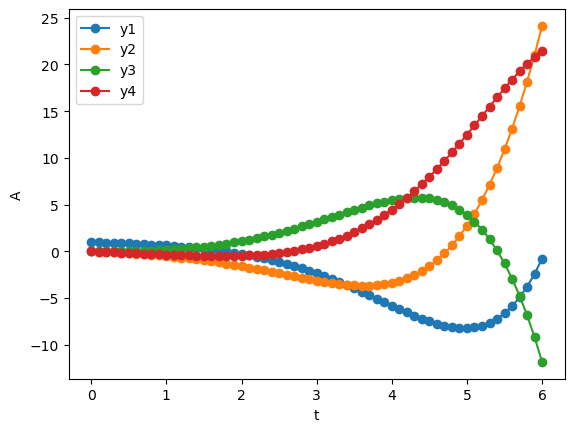

In [118]:
from numpy.linalg import eig # import the eig function
# The system of ODEs is coupled! Eigenanalysis lets us diagonalize the system matrix,
# making the solution trivial!

# Set up system of equations:
A = np.array([[-0.3,0.7,-0.4,-0.2],[-0.3,0.6,-0.2,0.7],[-0.1,-0.8,0,-0.4],[-0.3,0.3,0.7,0.3]]) # coupled system matrix
y_init = np.array([[1],[0],[0],[0]]) # initial conditions

# Eigenanalysis
D, U = eig(A) # Get eigenvalues and vectors
c = np.linalg.inv(U) @ y_init #solve for initial consitions

# Time axis
dt = 0.1
t = np.arange(0,6+dt,dt)
t.shape = (1,len(t))

# The solution:
y = c[0]*U[:,[0]]*np.exp(D[0]*t) + c[1]*U[:,[1]]*np.exp(D[1]*t) + c[2]*U[:,[2]]*np.exp(D[2]*t) + c[3]*U[:,[3]]*np.exp(D[3]*t)

# Plotting:
fig, ax = plt.subplots()
for i in range(4):
    ax.plot(t.T,np.real(y[[i],:]).T,'o-')
ax.legend(['y1','y2','y3','y4'])
ax.set_xlabel('t');
ax.set_ylabel('A');


## Exercise 10.7: Another Second-Order ODE

Solving the second-order Airy function numerically. The code below follows Mike's closely, but does not stop to pull out specific eigenvalues.

There is a way to vectorize this code (Turn two for loops into one for loop). Vectorization is crucial for those looking to write efficient code and work on high-dimensional problems. Try to vectorize the following code block to arrive at the same plots. The approach first creates a 3D matrix A of stacked 2D matrices. eig will compute eigenvectors and eigenvalues for each 2D matrix along the stack. inv works in the same way. 

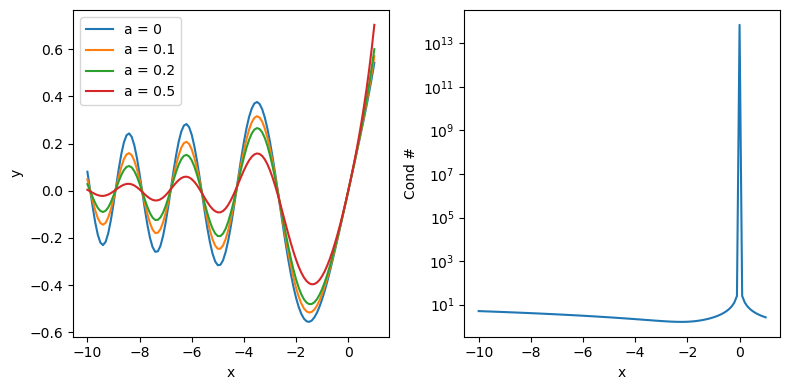

In [119]:
from numpy.linalg import eig # import the eig function
dx = 0.1 # step
x = np.arange(-10,1+dx,dx) # independent var
N = len(x) # length of x-axis
a = np.array([0, 0.1, 0.2, 0.5]) # free parameter
y = np.zeros((len(a.T),N), dtype=np.complex64) # Initialize sol as complex array
cx = np.zeros((1,N)) # Initialize condtion number
y0 = np.array([[0,0.5]]).T # initial conditions

# Loop through and solve
for i in range(len(a)):
    for j in range(N):
        A = np.array([[0,1],[0.5*x[j],a[i]]])
        D, U = eig(A) # Get eigenvalues and vectors
        c = np.linalg.inv(U) @ y0 #solve for initial conditions
        y[i,j] = c[0,0]*U[0,0]*np.exp(D[0]*x[j]) + c[1,0]*U[0,1]*np.exp(D[1]*x[j]) # get y 
        cx[0,j] = np.linalg.cond(A) # save condition number

# Plotting
fig, ax = plt.subplots(1,2,figsize=(8,4))
for ai in range(4):
    ax[0].plot(x,np.real(y[ai,:]));
ax[0].legend(['a = 0','a = 0.1','a = 0.2','a = 0.5']);
ax[0].set_xlabel('x');
ax[0].set_ylabel('y');

ax[1].semilogy(x,cx.T)
ax[1].set_xlabel('x')
ax[1].set_ylabel('Cond #')

fig.tight_layout()


## Excercise 10.8: Introduction to PCA

- I leave the calculation of the Mahalanobis distance to the reader. This is a good exercise in plotting as there are many approaches to develop a filled elliptical region on the plot.
- Do you get the same coviariance matrix back after making the measurements? Try to compute a covariance matrix from the data matrix m. Does it match the defined K matrix?

Text(0, 0.5, 'y')

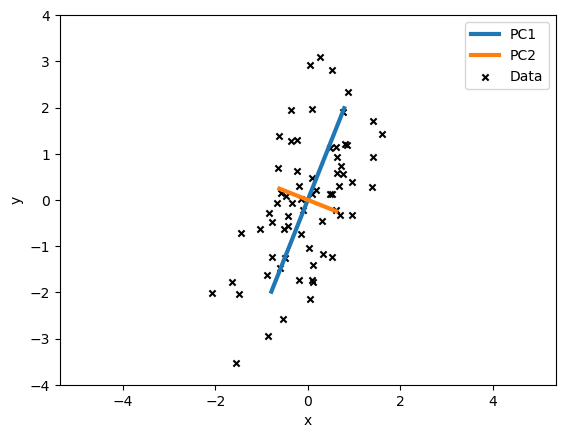

In [120]:
from numpy.linalg import eig # import the eig function
sx, sy, r = 1, 2, 1/np.sqrt(2) # std in x and y and r=rho
K  = np.array([[sx**2,r*sx*sy],[r*sx*sy,sy**2]]) # Define Covariance matrix K
D, U = eig(K) # Get eigenvalues and vectors
idxs = np.argsort(D)[::-1] # sort then reverse order for descending
D = D[idxs]
U = U[:,idxs]
# Ki = U@np.array([[D[0],0],[0,D[1]]])@np.linalg.inv(U) # Check if reordering is still valid

SV = np.sqrt(D) # Singular values

# Plotting the principle components
plt.plot([-SV[0]*U[0,0],SV[0]*U[0,0]],[-SV[0]*U[1,0],SV[0]*U[1,0]], lw=3); # Plot eigenvectors scaled by singular values
plt.plot([-SV[1]*U[0,1],SV[1]*U[0,1]],[-SV[1]*U[1,1],SV[1]*U[1,1]], lw=3); # Plot eigenvectors scaled by singular values
plt.axis('equal'); # USE THIS OTHERWISE THE VECTORS WILL NOT LOOK PERPENDICULAR


# ADD data from this distribution to the plot
n = 70
m = np.random.multivariate_normal([0,0], K, n) # mvnnorm in MATLAB. Last number is the number of samps
plt.scatter(m[:,0],m[:,1],s=20,c='k',marker='x') # scatter the data
plt.xlim([-4,4])
plt.ylim([-4,4])
plt.legend(['PC1','PC2','Data']);
plt.xlabel('x')
plt.ylabel('y')

## Exercise 11.2: Singular value decomposition (SVD)
- Comparison of methods for finding principle components. 

Population mean in x and y: 40, 60
--------------------
Estimated mean in x and y: 39.31, 59.00
--------------------
Population covariance matrix:
[[100. 180.]
 [180. 400.]]
--------------------
Estimated covriance matrix:
[[ 87.26504171 150.43188804]
 [150.43188804 342.33955811]]
--------------------
Principle components method 1 EIG:
[[-0.42031124 -0.90738   ]
 [-0.90738     0.42031124]]
--------------------
Principle components method 2 SVD:
[[-0.42031124 -0.90738   ]
 [ 0.90738    -0.42031124]]
--------------------
Principle components method 3 Scikit learn PCA:
[[ 0.42031124  0.90738   ]
 [ 0.90738    -0.42031124]]
--------------------


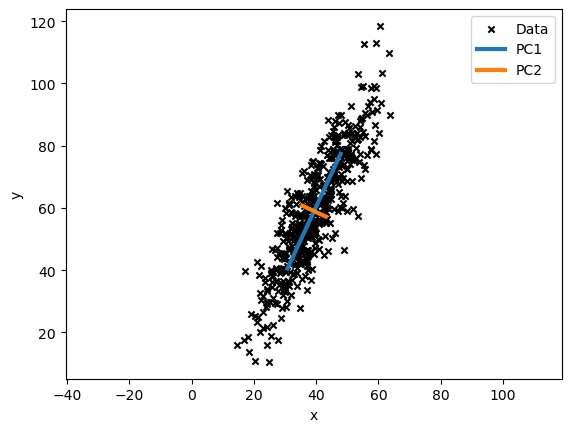

In [121]:
from numpy.linalg import eig # import the eig function
from numpy.linalg import svd # import the svd function
from sklearn.decomposition import PCA

M, mx, my = 500, 40, 60 # Number of samples, mean of x and mean of y
sx, sy, r = 10, 20, 0.9 # std in x and y and r=rho
K  = np.array([[sx**2,r*sx*sy],[r*sx*sy,sy**2]]) # Define Covariance matrix K
X = np.random.multivariate_normal([mx,my], K, M) # mvnnorm in MATLAB. Last number is the number of samps
# Plot the data
plt.scatter(X[:,0],X[:,1],s=20,c='k',marker='x') # scatter the data
plt.xlabel('x')
plt.ylabel('y')
plt.axis('equal'); # USE THIS OTHERWISE THE VECTORS WILL NOT LOOK PERPENDICULAR

# COMPARISON OF ESTIMATION TO POPULATION STATISTICS
muX, covX = np.mean(X,axis=0), np.cov(X.T)
print(f'Population mean in x and y: {mx}, {my}')
print("-" * 20)  # Prints 20 dashes
print(f'Estimated mean in x and y: {muX[0]:4.2f}, {muX[1]:4.2f}')
print("-" * 20)  # Prints 20 dashes
print('Population covariance matrix:')
print(K)
print("-" * 20) 
print('Estimated covriance matrix:')
print(covX)
print("-" * 20)  # Prints 20 dashes


# METHOD 1: USING EIGENANALYSIS
D, U = eig(covX) # Get eigenvalues and vectors
idxs = np.argsort(D)[::-1] # sort then reverse order for descending
D = D[idxs]
U = U[:,idxs]
print('Principle components method 1 EIG:')
print(U)
print("-" * 20)  # Prints 20 dashes
SV = np.sqrt(D) # Singular values
# Plotting the principle components
plt.plot([-SV[0]*U[0,0],SV[0]*U[0,0]]+muX[0],[-SV[0]*U[1,0],SV[0]*U[1,0]]+muX[1], lw=3); # Plot eigenvectors scaled by singular values
plt.plot([-SV[1]*U[0,1],SV[1]*U[0,1]]+muX[0],[-SV[1]*U[1,1],SV[1]*U[1,1]]+muX[1], lw=3); # Plot eigenvectors scaled by singular values

# METHOD 2: USING SVD
V, SV, U = svd(X - muX) # Get eigenvalues and vectors
idxs = np.argsort(SV)[::-1] # sort then reverse order for descending
SV = SV[idxs]
U = U[:,idxs]
print('Principle components method 2 SVD:')
print(U)
print("-" * 20)  # Prints 20 dashes
# Plotting the principle components
# SV = np.sqrt(SV)
# plt.plot([-SV[0]*U[0,0],SV[0]*U[0,0]]+muX[0],[-SV[0]*U[1,0],SV[0]*U[1,0]]+muX[1], lw=3); # Plot eigenvectors scaled by singular values
# plt.plot([-SV[1]*U[0,1],SV[1]*U[0,1]]+muX[0],[-SV[1]*U[1,1],SV[1]*U[1,1]]+muX[1], lw=3); # Plot eigenvectors scaled by singular values


# METHOD 2: USING Scikit learn's PCA (NEED to install scikit learn toolbox to use)
pca = PCA(n_components=2)
X_fit = pca.fit_transform((X-muX))
U = pca.components_
print('Principle components method 3 Scikit learn PCA:')
print(U)
print("-" * 20)  # Prints 20 dashes
# Plotting the principle components
# SV = np.sqrt(pca.singular_values_)
# plt.plot([-SV[0]*U[0,0],SV[0]*U[0,0]]+muX[0],[-SV[0]*U[1,0],SV[0]*U[1,0]]+muX[1], lw=3); # Plot eigenvectors scaled by singular values
# plt.plot([-SV[1]*U[0,1],SV[1]*U[0,1]]+muX[0],[-SV[1]*U[1,1],SV[1]*U[1,1]]+muX[1], lw=3); # Plot eigenvectors scaled by singular values

plt.legend(['Data','PC1','PC2']);

We find the same principle components (with sign ambiguity) across all three methods. Plot uses results from method 1. 

## Exercise 11.3a: Temporal resolution of an LTI system

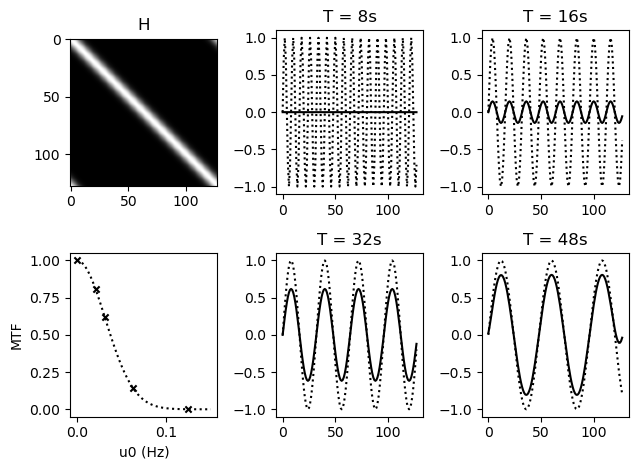

In [122]:
from scipy.linalg import toeplitz # for easy teoplitz marix generation
# Mike starts at t=1 for easy indexing. I am going to start at t=0 and end at 127s, still with dimensions of 128x128
M, s = 128, 5 # Number of samples and the standard dev of the gaussian impulse response
tt = np.arange(0,M) # initialize time axis
h = np.zeros((1,M)) # initialize impulse response

# Create h. I recommend plotting h to check that its the circulant impulse response
h[0,0:int(M/2)+1] = np.exp(-(tt[0:int(M/2)+1])**2/(2*s**2))/(s*np.sqrt(2*np.pi))
h[0,-1:int(M/2):-1] = h[0,1:int(M/2)]

# Form toeplitz
H = toeplitz(h)
fig, ax = plt.subplots(2,3)
ax[0,0].imshow(H,cmap='gray');
ax[0,0].set_title('H')

# Compute modulation transfer using sinusoids with different periods
T0 = np.array([8,16,32,48])
X1 = np.zeros((len(T0),M))
for i in range(len(T0)): # generate input signals (pure tone sine waves)
    T = T0[i]
    X1[i,:] = np.sin(2*np.pi*tt/T0[i])
Y1 = H @ X1.T # convolve

u0 = np.concatenate(([0], 1/T0[::-1])) # frq axis
MTF = np.concatenate(([1], np.max(Y1,axis=0)[::-1])) # get MTF as the max of the output signal

# Predicted MTF
uu = np.linspace(0,0.15,100)
MTFp = np.exp(-2*np.pi**2*5**2*uu**2)

ax[1,0].scatter(u0,MTF,s=20,c='k',marker='x')
ax[1,0].plot(uu,MTFp,'k:')
ax[1,0].set_xlabel('u0 (Hz)')
ax[1,0].set_ylabel('MTF')

# Plotting the I/O pairs with labeled periods
ax[0,1].plot(tt,X1[0,:],'k:')
ax[0,1].plot(tt,Y1[:,0],'k')
ax[0,1].set_title('T = '+str(T0[0])+'s')
ax[0,2].plot(tt,X1[1,:],'k:')
ax[0,2].plot(tt,Y1[:,1],'k')
ax[0,2].set_title('T = '+str(T0[1])+'s')
ax[1,1].plot(tt,X1[2,:],'k:')
ax[1,1].plot(tt,Y1[:,2],'k')
ax[1,1].set_title('T = '+str(T0[2])+'s')
ax[1,2].plot(tt,X1[3,:],'k:')
ax[1,2].plot(tt,Y1[:,3],'k')
ax[1,2].set_title('T = '+str(T0[3])+'s')
fig.tight_layout()

## Exercise 11.3b: Temporal resolution of an LTV system

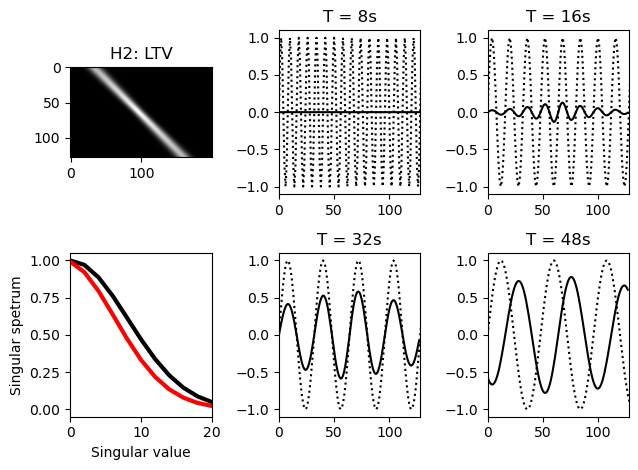

In [123]:
from scipy.linalg import toeplitz # for easy teoplitz marix generation
from numpy.linalg import svd # import the svd function

M, N, s1, ds = 128, 200, 7, 2 # Number of samples and parameters associated with the time dependent standard deviation of the gaussian

t = np.arange(0,N) # time
s = np.zeros((M)) # std

# Create s - a vector of standard deviations to alter the impulse response
for i in range(int(M/2)):
    s[i] = s1 - ds*i/(M/2)
    s[M-i-1] = s[i]

# plt.plot(s)

# Create the LTV impulse response matrix
H2 = np.zeros((M,N))
for j in range(M):
    H2[j,:] = np.exp(-(t-(j+M/4))**2/(2*s[j]**2))/(s[j]*np.sqrt(2*np.pi))

# Image H2
fig, ax = plt.subplots(2,3)
ax[0,0].imshow(H2,cmap='gray');
ax[0,0].set_title('H2: LTV');

# Apply sinusoids with different periods as input
T0 = np.array([8,16,32,48])
X2 = np.zeros((len(T0),N))
for i in range(len(T0)): # generate input signals (pure tone sine waves)
    T = T0[i]
    X2[i,:] = np.sin(2*np.pi*t/T0[i])
Y2 = H2 @ X2.T # convolve and get outputs (mult)

# Compute the singular spectra of H and H2
_, S1, _ = svd(H) # Get singular values
_, S2, _ = svd(H2)

# Reorder
idxs = np.argsort(S1)[::-1] # sort then reverse order for descending
S1 = S1[idxs]
idxs = np.argsort(S2)[::-1] # sort then reverse order for descending
S2 = S2[idxs]
# plot singular value spectra
ax[1,0].plot(tt[::2],S1[::2],'k',lw=3)
ax[1,0].plot(tt[::2],S2[::2],'r',lw=3)
ax[1,0].set_xlim([0,20])
ax[1,0].set_xlabel('Singular value')
ax[1,0].set_ylabel('Singular spetrum')

# Plotting the I/O pairs with labeled periods
ax[0,1].plot(t,X2[0,:],'k:')
ax[0,1].plot(t[0:M],Y2[:,0],'k')
ax[0,1].set_title('T = '+str(T0[0])+'s')
ax[0,1].set_xlim([0,128])
ax[0,2].plot(t,X2[1,:],'k:')
ax[0,2].plot(t[0:M],Y2[:,1],'k')
ax[0,2].set_title('T = '+str(T0[1])+'s')
ax[0,2].set_xlim([0,128])
ax[1,1].plot(t,X2[2,:],'k:')
ax[1,1].plot(t[0:M],Y2[:,2],'k')
ax[1,1].set_title('T = '+str(T0[2])+'s')
ax[1,1].set_xlim([0,128])
ax[1,2].plot(t,X2[3,:],'k:')
ax[1,2].plot(t[0:M],Y2[:,3],'k')
ax[1,2].set_title('T = '+str(T0[3])+'s')
ax[1,2].set_xlim([0,128])
fig.tight_layout()

## Example 13.1: Time-dependence of a network graph

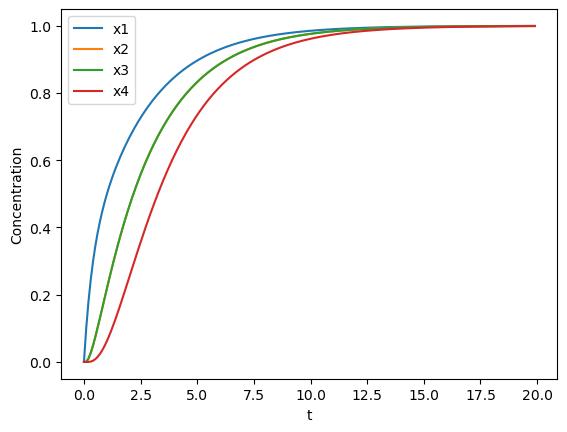

In [124]:
# Define stochiometric matrix S
S = np.array([[1,-1,-1,0,0,0],[0,1,0,1,-1,0],[0,0,1,-1,0,0],[0,0,0,0,1,-1]])
T, T0 = 0.1, 20 # dt and end of the time axis
t = np.arange(0,T0,T) # define time axis
N = len(t) # length of time array
X = np.zeros((S.shape[0],N)) # Matrix initialized to store 4 concentrations over time
x0 = np.array([0,0,0,0]) # init cond
X[:,0] = x0 # Initialize all metobolite concentrations
k = np.ones(6) # rate constants
kn = np.array([0,0,1,1,0,0]) # reversible rates

# Loop through each time point
for i in range(1,N):
  f = np.array([[k[0],k[1]*X[0,i-1],k[2]*X[0,i-1]-kn[2]*X[2,i-1],
                 k[3]*X[2,i-1]-kn[3]*X[1,i-1],k[4]*X[1,i-1],k[5]*X[3,i-1]]]).T # Flux
  dx = S @ f*T # time derivative
  X[:,[i]] = X[:,[i-1]] + dx # Find current metabolite concentration

# Plotting
plt.plot(t,X.T);
plt.legend(['x1','x2','x3','x4']);
plt.xlabel('t');
plt.ylabel('Concentration');

## Exercise 13.2: Perterbation of the system in example 13.1

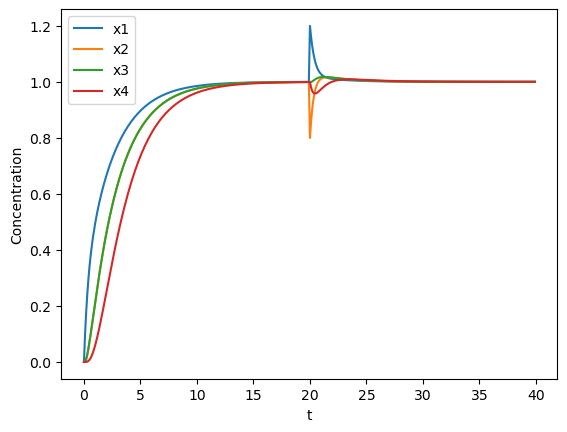

In [125]:
# Define stochiometric matrix S
S = np.array([[1,-1,-1,0,0,0],[0,1,0,1,-1,0],[0,0,1,-1,0,0],[0,0,0,0,1,-1]])
T, T0 = 0.1, 40 # dt and end of the time axis
t = np.arange(0,T0,T) # define time axis
t2 = np.arange(0,20,T) # define time axis(20)
M = len(t) # length of time array
N = len(t2)
X = np.zeros((S.shape[0],M)) # Matrix initialized to store 4 concentrations over time
x0 = np.array([0,0,0,0]) # init cond
X[:,0] = x0 # Initialize all metobolite concentrations
k = np.ones(6) # rate constants
kn = np.array([0,0,1,1,0,0]) # reversible rates

# Loop through each time point
for i in range(1,N):
  f = np.array([[k[0],k[1]*X[0,i-1],k[2]*X[0,i-1]-kn[2]*X[2,i-1],
                 k[3]*X[2,i-1]-kn[3]*X[1,i-1],k[4]*X[1,i-1],k[5]*X[3,i-1]]]).T # Flux
  dx = S @ f*T # time derivative
  X[:,[i]] = X[:,[i-1]] + dx # Find current metabolite concentration

# Adjust the concentration suddenly (perturb the system!)
X[:,N] = X[:,N-1]
X[0,N] = 1.2*X[0,N]
X[1,N] = 0.8*X[1,N]
# Loop through each time point
for i in range(N+1,M):
  f = np.array([[k[0],k[1]*X[0,i-1],k[2]*X[0,i-1]-kn[2]*X[2,i-1],
                 k[3]*X[2,i-1]-kn[3]*X[1,i-1],k[4]*X[1,i-1],k[5]*X[3,i-1]]]).T # Flux
  dx = S @ f*T # time derivative
  X[:,[i]] = X[:,[i-1]] + dx # Find current metabolite concentration

# Plotting
plt.plot(t,X.T);
plt.legend(['x1','x2','x3','x4']);
plt.xlabel('t');
plt.ylabel('Concentration');

## Example 14.1: Linear discriminant analysis (LDA)

Net fractional error is: 0.11


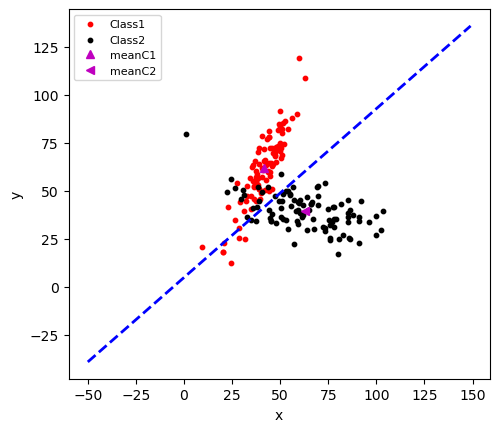

In [126]:
# Initialize params
M1, M2 = 100, 100
M = M1+M2
m1x, m1y, m2x, m2y = 40, 60, 60, 40

m1 = [m1x, m1y] # vector of mean values
m2 = [m2x, m2y]

# Form Cov matrices
s1x, s1y, r1, s2x, s2y, r2 = 10, 20, 0.9, 20, 10, -0.6
K1 = np.array([[s1x**2,r1*s1x*s1y],[r1*s1x*s1y,s1y**2]])
K2 = np.array([[s2x**2,r2*s2x*s2y],[r2*s2x*s2y,s2y**2]])
# Simulate the forward problem (measurements from distribution)
X1 = np.random.multivariate_normal(m1,K1,M1)
X2 = np.random.multivariate_normal(m2,K2,M2)

# Get estimated sample statistics
X1b, K1x = np.mean(X1,axis=0), np.cov(X1.T)
X2b, K2x = np.mean(X2,axis=0), np.cov(X2.T)

# Plot
fig, ax = plt.subplots(1,1)
ax.scatter(X1[:,0],X1[:,1],s=10,c='r')
ax.scatter(X2[:,0],X2[:,1],s=10,c='k')
ax.set_aspect('equal')
ax.set_xlabel('x')
ax.set_ylabel('y')
# add means to plot
ax.plot(X1b[0],X1b[1],'m^',lw=5)
ax.plot(X2b[0],X2b[1],'m<',lw=5)
ax.legend(['Class1','Class2','meanC1','meanC2'],loc='best',fontsize=8)

# Linear discriminant analysis! # Using the formula (14.5)
a=2*(X2b-X1b) @ np.linalg.inv(((K1x+K2x)/2))
b=X2b @ np.linalg.inv((K1x+K2x)/2) @ X2b.T-X1b @ np.linalg.inv((K1x+K2x)/2) @ X1b.T
# Plot the line
x = np.arange(-50,150)
y = (b-a[0]*x)/a[1]
ax.plot(x,y,'b--',lw=2)

# Characterize error
e1, e2 = 0, 0

for j in range (M1):
  yy1 = (b-a[0]*X1[j,0])/a[1] # predict y based on x for LD function
  yy2 = (b-a[0]*X2[j,0])/a[1]
  if X1[j,1]<yy1: e1+=1 # count if below
  if X2[j,1]>yy2: e2+=1 # count if above
print(f'Net fractional error is: {(e1+e2)/M:4.2f}') # Display results to screen

## Excercise 14.1: LDA (with PCA)

Net fractional error (3D) is: 0.22


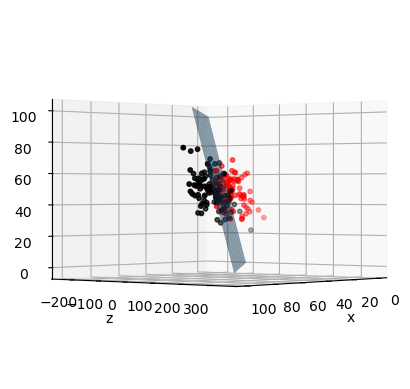

In [127]:
# Define Params
M = 100 # Sample size per class
m1x, m1y, m1z = 43, 50, 50 # Means c1
m2x, m2y, m2z = 57, 50, 50 # Means c2
s1x, s1y, s1z, r1xy, r1xz, r1yz = 10, 10, 7, 0.4, 0.1, -0.1 # STDEVs and CORRs c1
s2x, s2y, s2z, r2xy, r2xz, r2yz = 20, 10, 10, -0.6, -0.1, 0.8 # STDEVs and CORRs c2

m1 = np.array([m1x, m1y, m1z]) # Means for class 1
m2 = np.array([m2x, m2y, m2z]) # Means for class 2

K1 = np.array([[s1x**2, r1xy*s1x*s1y, r1xz*s1x*s1z],
               [r1xy*s1x*s1y, s1y**2, r1yz*s1y*s1z],
               [r1xz*s1x*s1z, r1yz*s1y*s1z, s1z**2]]) # COV matrix for c1 (3x3)

K2 = np.array([[s2x**2, r2xy*s2x*s2y, r2xz*s2x*s2z],
               [r2xy*s2x*s2y, s2y**2, r2yz*s2y*s2z],
               [r2xz*s2x*s2z, r2yz*s2y*s2z, s2z**2]]) # COV matrix for c2 (3x3) - unused

# Simulate the forward problem (measurements from distribution)
X1 = np.random.multivariate_normal(m1,K1,M)
X2 = np.random.multivariate_normal(m2,K1,M)

# Get estimated sample statistics
X1b, K1x = np.mean(X1,axis=0), np.cov(X1.T)
X2b, K2x = np.mean(X2,axis=0), np.cov(X2.T)

# Linear discriminant analysis! # Using the formula (14.5)
a=2*(X2b-X1b) @ np.linalg.inv(((K1x+K2x)/2))
b=X2b @ np.linalg.inv((K1x+K2x)/2) @ X2b.T-X1b @ np.linalg.inv((K1x+K2x)/2) @ X1b.T

# In python the y axis is not up-down. I usually plot using (x,z,y).
fig, ax = plt.subplots(subplot_kw={'projection':'3d'})
ax.scatter(X1[:,0],X1[:,2],X1[:,1],s=10,c='r')
ax.scatter(X2[:,0],X2[:,2],X2[:,1],s=10,c='k')

# Rather than using patches (which can be done), I will just create a mesh grid
# and use plot_surface.
xp, yp = np.meshgrid(np.linspace(0,100,10),np.linspace(0,100,10))
zp = (b-a[1]*yp-a[0]*xp)/a[2] # Find z
ax.plot_surface(xp,zp,yp,alpha=0.5) # plot the LD plane
ax.view_init(elev=0, azim=40, roll=0) # viewing angle. I suggest playing with azim.
ax.set_xlabel('x')
ax.set_ylabel('z')
ax.set_zlabel('y')
e1, e2 = 0,0
for j in range(M):
  zz1 = (b-a[1]*X1[j,1]-a[0]*X1[j,0])/a[2] # predict z based on x and y for LD function
  zz2 = (b-a[1]*X2[j,1]-a[0]*X2[j,0])/a[2]
  if X1[j,2]<zz1: e1+=1 # count if below
  if X2[j,2]>zz2: e2+=1 # count if above
print(f'Net fractional error (3D) is: {(e1+e2)/(2*M):4.2f}') # Display results to screen

- For the next part of the code, we project the data onto either 2 (2D) or 1 (1D) of the principal components and perform LDA.
- I recommend trying a couple of things:
    1. Set up this block and the previous one to calculate errors over many trials and generate fig 14.5e.
    2. Change sample size and some of the population statistics to get a feel for things
- Be careful. In some situations you may need to switch which class is above and below the line.  

Net fractional error (2D) is: 0.44
1D cutoff is at: 53.00
Net fractional error (1D) is: 0.73


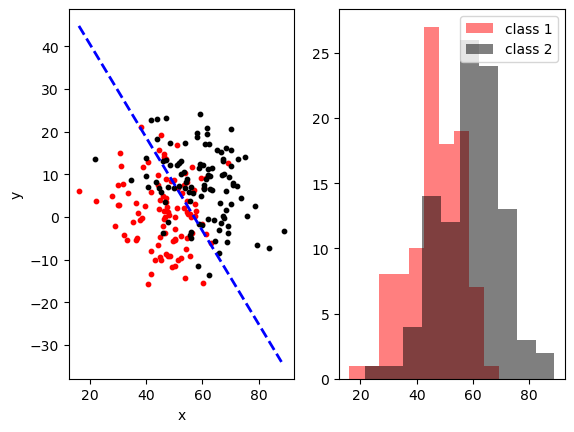

In [128]:
# Omitting the 3d plot showing each PC in 3D, though it is a another good exercise in python plotting.
# Start with the 3d plot above if wanted to create the 3d plot.
from numpy.linalg import svd
# Combine data sets and perform SVD
X = np.concatenate((X1,X2),axis=0)
Xb = np.mean(X, axis=0)
_, _, U = svd(X-Xb)

# Project the data onto the PCs
Y = X @ U
# Parse data sets for analysis
Y1 = Y[0:M,0:2]
Y2 = Y[M::,0:2]
# Plot the data 
fig, ax = plt.subplots(1,2)
ax[0].scatter(Y1[:,0],Y1[:,1],s=10,c='r')
ax[0].scatter(Y2[:,0],Y2[:,1],s=10,c='k')
# ax[0].set_aspect('equal')
ax[0].set_xlabel('x')
ax[0].set_ylabel('y')


# Come up with an x axis to plot the LDF
xp = np.arange(min([np.min(Y1[:,0]),np.min(Y2[:,0])]),max([np.max(Y1[:,0]),np.max(Y2[:,0])]))

# Get estimated sample statistics
Y1b, K1y = np.mean(Y1,axis=0), np.cov(Y1.T)
Y2b, K2y = np.mean(Y2,axis=0), np.cov(Y2.T)


# Linear discriminant analysis 2 PCs (2D)! # Using the formula (14.5)
a=2*(Y2b-Y1b) @ np.linalg.inv(((K1y+K2y)/2))
b=Y2b @ np.linalg.inv((K1y+K2y)/2) @ Y2b.T-Y1b @ np.linalg.inv((K1y+K2y)/2) @ Y1b.T
# Plot the line
y = (b-a[0]*xp)/a[1]
ax[0].plot(xp,y,'b--',lw=2)

# Characterize error
e1, e2 = 0, 0

for j in range (M):
  yy1 = (b-a[0]*Y1[j,0])/a[1] # predict y based on x for LD function
  yy2 = (b-a[0]*Y2[j,0])/a[1]
  if Y1[j,1]>yy1: e1+=1 # count if above
  if Y2[j,1]<yy2: e2+=1 # count if below
print(f'Net fractional error (2D) is: {(e1+e2)/M:4.2f}') # Display results to screen


# Linear discriminant analysis 1 PCs (1D)!
ax[1].hist(Y1[:,0],alpha=0.5,color='r')
ax[1].hist(Y2[:,0],alpha=0.5,color='k')
ax[1].legend(['class 1','class 2'])
a=2*(Y2b[0]-Y1b[0]) /(((K1y[0,0]+K2y[0,0])/2))
b=Y2b[0]**2 / ((K1y[0,0]+K2y[0,0])/2) -Y1b[0]**2 /((K1y[0,0]+K2y[0,0])/2)
xpp = b/a # LDF for 1D data
print(f'1D cutoff is at: {xpp:4.2f}')
# Characterize error
e1, e2 = 0, 0
for j in range (M):
  if Y1[j,0]<xpp: e1+=1 # count if below
  if Y2[j,0]>xpp: e2+=1 # count if above
print(f'Net fractional error (1D) is: {(e1+e2)/(2*M):4.2f}') # Display results to screen

## Example 16.19: Quantum Fourier Transform

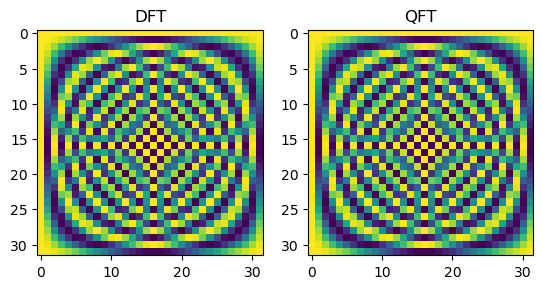

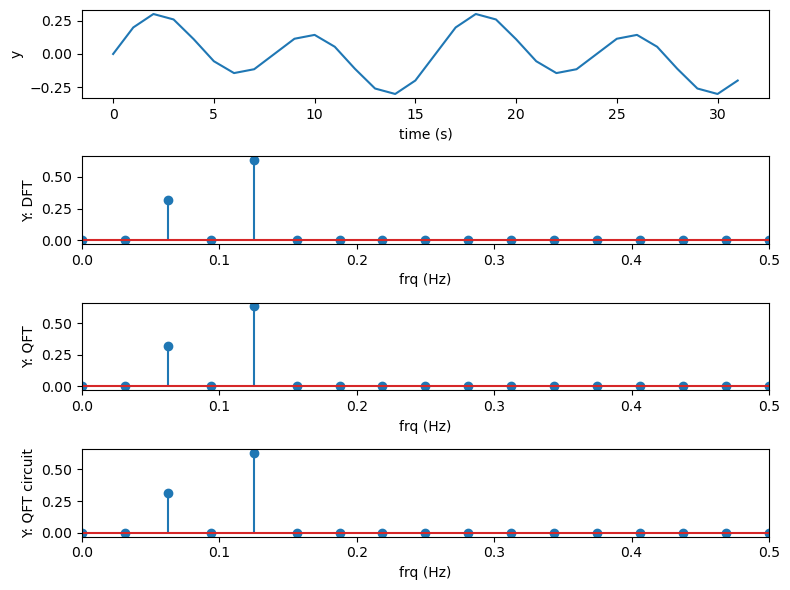

In [129]:
from numpy import pi as pi
# (a) build the DFT and QFT matrices
n = 5 # number of qubits
N = 2**n # number of basis states
q = np.exp(1j*2*pi/N) # Fourier kernel

# Initialize: J-index mat, Qd-DFT mat (complex), Qq-QFT mat (complex)
J, Qd, Qq = np.zeros((N+1,N)), np.zeros((N,N),dtype=complex), np.zeros((N,N),dtype=complex)
# J is one row larger than Qd and Qq to pull the correct indices
for ind in range(N): # form index matrix J - first row and col are zeros
    J[ind+1,:] = np.arange(0,(ind+1)*(N),ind+1) # QFT matrix index
    for k in range(N): # frequency
        Qd[ind,k] = q**(-(ind*k)) # DFT matrix (negative exponent)
        Qq[ind,k] = q**(np.mod(J[ind,k],N)) # QFT matrix (positive exponent)

# Show images of the matrices! 
fig, ax = plt.subplots(nrows=1,ncols=2) 
ax[0].imshow(np.real(Qd))
ax[0].set_title('DFT')
ax[1].imshow(np.real(Qq))
ax[1].set_title('QFT')
plt.show()

#%% Set up time and frq axis
m = np.arange(0,N) # time axis 
du, U = 1/N, 1 # frq axis params (step size, ~bandwidth)
u = np.arange(0,U,du) # frq axis

A1, frq1 = 1, 1/(N/2) # amplitude and frq of 1st sin wave
A2, frq2 = 2, 1/(N/4) # amplitude and frq of 2nd sin wave 
y = (A1*np.sin(2*pi*m*frq1)+A2*np.sin(2*pi*m*frq2)) # sum of waves
qsum = np.sum(y**2) 
y/=np.sqrt(qsum) # normalize the input energy

Yd = Qd @ y/np.sqrt(N) # DFT (matrix mult)
Yq = Qq @ y/np.sqrt(N) # QFT (matrix mult)

# Plotting just these results
fig, ax = plt.subplots(4,1, figsize=(8,6))
ax[0].plot(m,y)
ax[0].set_xlabel('time (s)')
ax[0].set_ylabel('y')
ax[1].stem(u,np.abs(Yd))
ax[1].set_xlabel('frq (Hz)')
ax[1].set_ylabel('Y: DFT')
ax[1].set_xlim(0,0.5)
ax[2].stem(u,np.abs(Yq))
ax[2].set_xlabel('frq (Hz)')
ax[2].set_ylabel('Y: QFT')
ax[2].set_xlim(0,0.5)
# fig.tight_layout()
# plt.show()

#%% (b) Program the QFT curcuit for n=5 qubits
ket0 = np.array([[1],[0]]) # basis state 0
ket1 = np.array([[0],[1]]) # basis state 1
x = np.zeros((1,n)) # dec array of bin values
Yqc = 0 

for i in range(N,2*N): # binary digit length
        yy = np.binary_repr(i) # Translate to binary
        for bit in range(n): # loop through each bit
            if yy[bit+1] =='1':
                x[0,bit] = 1
            else:
                x[0,bit] = 0
                
        X1 = ket0+ket1*np.exp(1j*2*pi*x[0,-1]/2) # LSB
        X2 = ket0+ket1*np.exp(1j*2*pi*((x[0,-2])/2+(x[0,-1])/2**2))       
        X3 = ket0+ket1*np.exp(1j*2*pi*(((x[0,-3])/2)+((x[0,-2])/2**2)+(x[0,-1])/2**3)) 
        X4 = ket0+ket1*np.exp(1j*2*pi*(((x[0,-4])/2)+((x[0,-3])/2**2)+((x[0,-2])/2**3)+(x[0,-1])/2**4)) 
        X5 = ket0+ket1*np.exp(1j*2*pi*(((x[0,-5])/2)+((x[0,-4])/2**2)+((x[0,-3])/2**3)+((x[0,-2])/2**4)+(x[0,-1])/2**5)) #MSB 
        Yqc = Yqc+y[i-N]*np.kron(X1,np.kron(X2,np.kron(X3,np.kron(X4,X5))))/(2**(n/2)) # Tensor prod and sum
# Plotting the rest!
ax[3].stem(u,np.abs(Yqc))
ax[3].set_xlabel('frq (Hz)')
ax[3].set_ylabel('Y: QFT circuit')
ax[3].set_xlim(0,0.5)
fig.tight_layout()
plt.show()